# Library and Data Imports and Standardization

In [ ]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalAveragePooling1D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras import regularizers # Import regularizers
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping
import time # Import time
import numpy as np # Import numpy
import pandas as pd # Import pandas
import matplotlib.pyplot as plt # Import matplotlib
import seaborn as sns # Import seaborn
from sklearn.model_selection import train_test_split # Import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report # Import metrics
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences
from tensorflow.keras.datasets import imdb # Import imdb
from pathlib import Path # Import Path

# Import ReduceLRonPlateau
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import the classification report
from sklearn.metrics import classification_report

# Import the f1 score
from sklearn.metrics import f1_score

# Import train test split
from sklearn.model_selection import train_test_split

# Import KFold
from sklearn.model_selection import KFold

# Import t-SNE and UMAP
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Import pickle
import pickle

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

import random
random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import the datasets

In [ ]:
path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/'

convabuse_imbalanced_filename = 'convabuse_imbalanced.csv'
convabuse_balanced_filename = 'convabuse_final.csv'

In [ ]:
# Import the datasets
convabuse_imbalanced = pd.read_csv(f'{path}{convabuse_imbalanced_filename}')
convabuse_resampled = pd.read_csv(f'{path}{convabuse_balanced_filename}')

In [ ]:
# X and y
imbalanced_X = convabuse_imbalanced.drop(columns=['abuse_level'])
imbalanced_y = convabuse_imbalanced['abuse_level']
resampled_X = convabuse_resampled.drop(columns=['abuse_level'])
resampled_y = convabuse_resampled['abuse_level']

In [ ]:
# Apply SMOTE on the imbalanced dataset to create a SMOTE rebalanced dataset
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
SMOTE_X, SMOTE_y = smote.fit_resample(convabuse_imbalanced, convabuse_imbalanced['abuse_level'])

In [ ]:
# Apply class weights
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(convabuse_imbalanced['abuse_level']), y=convabuse_imbalanced['abuse_level'])
class_weights_dict = dict(enumerate(class_weights))

In [ ]:
# Standard scale
scaler = StandardScaler()
imbalanced_X = scaler.fit_transform(imbalanced_X)
resampled_X = scaler.fit_transform(resampled_X)
SMOTE_X = scaler.fit_transform(SMOTE_X)

In [ ]:
# Train/test split
imbalanced_X_train, imbalanced_X_test, imbalanced_y_train, imbalanced_y_test = train_test_split(imbalanced_X, imbalanced_y, test_size=0.2, random_state=42, stratify=imbalanced_y)
resampled_X_train, resampled_X_test, resampled_y_train, resampled_y_test = train_test_split(resampled_X, resampled_y, test_size=0.2, random_state=42, stratify=resampled_y)
SMOTE_X_train, SMOTE_X_test, SMOTE_y_train, SMOTE_y_test = train_test_split(SMOTE_X, SMOTE_y, test_size=0.2, random_state=42, stratify=SMOTE_y)

## Convabuse Logistic Regression

In [ ]:
neural_network_TSNE = {}
neural_network_UMAP = {}

In [ ]:
def neural_network_modeling(X_train, X_test, y_train, y_test, dataset):
    results_list = []
    best_model = None
    best_accuracy = -float('inf') # Initialize best accuracy to negative infinity
    best_batch_size = None
    best_learning_rate = None
    best_history = None

    batch_sizes = [8]
    learning_rates = [1e-2]

    print(f"\nNeural Network Modeling - Dataset: {dataset}\n")

    for batch_size in batch_sizes:
        for learning_rate in learning_rates:
            print(f"Training with batch size: {batch_size}, learning rate: {learning_rate}")
            # Define the neural network model with L2 regularization
            model = Sequential([
                Dense(256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.L2(1e-3)),
                Dropout(0.1),
                Dense(128, activation='relu', kernel_regularizer=regularizers.L2(1e-3)),
                Dropout(0.15),
                Dense(64, activation='relu', kernel_regularizer=regularizers.L2(1e-3)),
                Dropout(0.2),
                Dense(len(np.unique(y_train)), activation='softmax')
            ])

            # Compile the model
            model.compile(optimizer=Adam(learning_rate=learning_rate),
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

            # Define the ReduceLROnPlateau callback
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_delta=1e-5,
                cooldown=0,
                min_lr=1e-8,
                verbose=1,
            )

            # Train the model with the callback and class weights
            start = time.time()
            history = model.fit(X_train, y_train,
                                epochs=200,
                                batch_size=batch_size,
                                validation_split=0.2,
                                verbose=1,
                                callbacks=[reduce_lr, EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])
            end = time.time()
            training_time = end - start

            # Evaluate on the validation set to find the best model
            val_loss, val_accuracy = model.evaluate(X_train[int(0.8 * len(X_train)):], y_train[int(0.8 * len(y_train)):], verbose=0)

            # Check if the current model has better validation accuracy
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                best_model = model
                best_batch_size = batch_size
                best_learning_rate = learning_rate
                best_history = history
                best_training_time = training_time

    print(f"\nBest model trained with batch size: {best_batch_size} and learning rate: {best_learning_rate}")
    print(f"Training time for best model: {best_training_time:.2f} seconds")


    # Evaluate the best model
    loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(best_model.predict(X_test), axis=1)
    f1 = f1_score(y_test, y_pred, average='weighted')
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\nDataset: {dataset}, Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate}, Final Test Accuracy: {accuracy}, Final Test F1-score: {f1}, Final Test Macro-F1-score: {macro_f1}")

    # Store results for the best model
    results_list.append((dataset, 'Neural Network', 'Adam', accuracy, f1, macro_f1, 0, best_batch_size, best_learning_rate))

    # Get feature importance (using absolute sum of weights in the first layer as a proxy)
    first_layer_weights = best_model.layers[0].get_weights()[0]
    overall_importance = np.sum(np.abs(first_layer_weights), axis=1)
    best_coefficients_data = dict(zip(range(len(overall_importance)), overall_importance))

    print("Feature Importance (based on first layer weights)")
    print(best_coefficients_data)

    # Plot the predictions that were generated as a histogram using seaborn
    sns.histplot(y_pred, kde=True)
    plt.title(f'Distribution of Predicted Classes for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
    plt.show()

    # Explicitly convert y_test to a pandas Series for plotting correlation
    try:
        y_test_series = pd.Series(y_test)
    except Exception as e:
        print(f"Could not convert y_test to pandas Series: {e}")
        y_test_series = None

    # Plot the predictions against a feature (need to select a feature)
    if isinstance(X_test, pd.DataFrame) and y_test_series is not None:
        correlation_series = X_test.corrwith(y_test_series).abs()
        if not correlation_series.empty and not correlation_series.isna().all():
            best_correlated_feature = correlation_series.idxmax()
            sns.scatterplot(x=X_test[best_correlated_feature], y=y_pred, hue=y_test, palette="hot")
            plt.title(f'Predictions vs Best Correlated Feature ({best_correlated_feature}) for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
            plt.show()
        else:
            print("Warning: Could not find a feature with sufficient correlation for plotting.")
    elif X_test.shape[1] > 0 and y_test_series is not None:
        sns.scatterplot(x=X_test[:, 0], y=y_pred, hue=y_test, palette="hot")
        plt.title(f'Predictions vs Feature 0 for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.show()
    else:
        print("Warning: X_test is not a pandas DataFrame and has no features for plotting.")


    # Sort the feature importances and plot the top 10 in descending order
    sorted_coefficients = sorted(best_coefficients_data.items(), key=lambda x: x[1], reverse=True)
    top_10_coefficients = sorted_coefficients[:10][::-1]
    top_10_features = [item[0] for item in top_10_coefficients]
    top_10_importances = [item[1] for item in top_10_coefficients]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_10_features, y=top_10_importances, palette="hot")
    plt.ylabel('Coefficient Value')
    plt.xlabel('Feature')
    plt.title(f'Top 10 Feature Importances for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
    plt.show()

    # Convert the results list into a dataframe
    results = pd.DataFrame(results_list, columns=["Dataset", "Model", "Optimizer", "Accuracy", "F1-score", "Macro F1-score", "Ratio", "Best Batch Size", "Best Learning Rate"])
    results['Importances'] = [best_coefficients_data]
    top_10_coefficients_dict = dict(top_10_coefficients)
    results['Feature Importances'] = [top_10_coefficients_dict]

    # Print a classification report
    print(classification_report(y_test, y_pred))

    # Print a classification matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='hot')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Classification Matrix for {dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
    plt.show()

    # Prepare data for t-SNE and UMAP plots, handling 2-feature datasets
    X_plot_tsne = None
    tsne_title_suffix = ""
    tsne_xlabel = ""
    tsne_ylabel = ""

    X_plot_umap = None
    umap_title_suffix = ""
    umap_xlabel = ""
    umap_ylabel = ""

    if X_test.shape[1] == 2:
        X_plot_tsne = X_test
        tsne_title_suffix = " (Original Features)"
        tsne_xlabel = "Feature 0"
        tsne_ylabel = "Feature 1"

        X_plot_umap = X_test
        umap_title_suffix = " (Original Features)"
        umap_xlabel = "Feature 0"
        umap_ylabel = "Feature 1"
    elif X_test.shape[1] > 2:
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
            X_plot_tsne = tsne.fit_transform(X_test)
            tsne_xlabel = 't-SNE Component 1'
            tsne_ylabel = 't-SNE Component 2'
        except Exception as e:
            print(f"Could not perform t-SNE reduction: {e}")

        try:
            reducer = umap.UMAP(random_state=42)
            X_plot_umap = reducer.fit_transform(X_test)
            umap_xlabel = 'UMAP Component 1'
            umap_ylabel = 'UMAP Component 2'
        except ImportError:
            print("UMAP library not found. Please install it with 'pip install umap-learn'")
        except Exception as e:
            print(f"Could not perform UMAP reduction: {e}")
    else: # X_test.shape[1] < 2, not enough features for 2D plot
        print("Warning: Not enough features in X_test for 2D t-SNE or UMAP visualization.")


    # Use t-sne and color code by the target variable
    if X_plot_tsne is not None:
        try:
            import matplotlib.patches as mpatches

            plt.figure(figsize=(10, 8))
            scatter = plt.scatter(X_plot_tsne[:, 0], X_plot_tsne[:, 1], c=y_test, cmap='hot', alpha=0.6)
            plt.title(f't-SNE Visualization - {dataset}{tsne_title_suffix} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
            plt.xlabel(tsne_xlabel)
            plt.ylabel(tsne_ylabel)

            classes = np.unique(y_test)
            colors = [scatter.cmap(scatter.norm(c)) for c in classes]
            handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
            plt.legend(handles=handles)

            plt.show()
        except Exception as e:
            print(f"Could not perform t-SNE visualization: {e}")

        # Use t-sne to plot correct vs incorrect predictions
        try:
            correct_predictions = (y_pred == y_test)

            plt.figure(figsize=(10, 8))
            scatter = plt.scatter(X_plot_tsne[:, 0], X_plot_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6)
            plt.title(f't-SNE Visualization of Correct vs Incorrect Predictions - {dataset}{tsne_title_suffix} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
            plt.xlabel(tsne_xlabel)
            plt.ylabel(tsne_ylabel)

            handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label='Incorrect'),
                       mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label='Correct')]
            plt.legend(handles=handles)

            plt.show()
        except Exception as e:
            print(f"Could not perform t-SNE visualization for correct vs incorrect predictions: {e}")

    # Use UMAP and color code by the target variable
    if X_plot_umap is not None:
        try:
            import umap.umap_ as umap

            plt.figure(figsize=(10, 8))
            scatter = plt.scatter(X_plot_umap[:, 0], X_plot_umap[:, 1], c=y_test, cmap='hot', alpha=0.6)
            plt.title(f'UMAP Visualization - {dataset}{umap_title_suffix} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
            plt.xlabel(umap_xlabel)
            plt.ylabel(umap_ylabel)

            classes = np.unique(y_test)
            colors = [scatter.cmap(scatter.norm(c)) for c in classes]
            handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
            plt.legend(handles=handles)

            plt.show()
        except ImportError:
            print("UMAP library not found. Please install it with 'pip install umap-learn'")
        except Exception as e:
            print(f"Could not perform UMAP visualization: {e}")

    neural_network_TSNE[dataset] = X_plot_tsne
    neural_network_UMAP[dataset] = X_plot_umap

    return results


Neural Network Modeling - Dataset: Convabuse

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
2013/2013 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.4952 - loss: 1.0040 - val_accuracy: 0.4720 - val_loss: 0.9140 - learning_rate: 0.0100
Epoch 2/200
2013/2013 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4947 - loss: 0.9077 - val_accuracy: 0.5289 - val_loss: 0.8723 - learning_rate: 0.0100
Epoch 3/200
2013/2013 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5003 - loss: 0.9011 - val_accuracy: 0.4964 - val_loss: 0.8872 - learning_rate: 0.0100
Epoch 4/200
2013/2013 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5081 - loss: 0.8944 - val_accuracy: 0.5386 - val_loss: 0.8821 - learning_rate: 0.0100
Epoch 5/200
2013/2013 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5023 - loss: 0.9069 - val_accuracy: 0.4723 - val_loss: 0.9243 - learning_rate: 0.0100
Epoch 6/200
2013/2013 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4983 - loss: 0.9131 - val_accuracy: 0.5374 - val_loss: 0.88

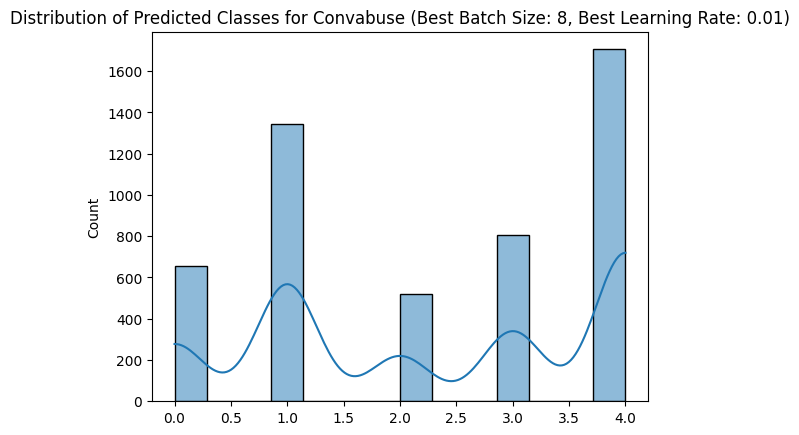

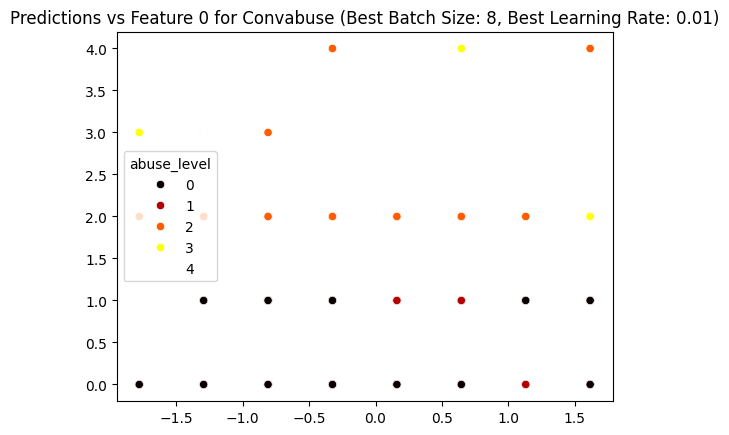

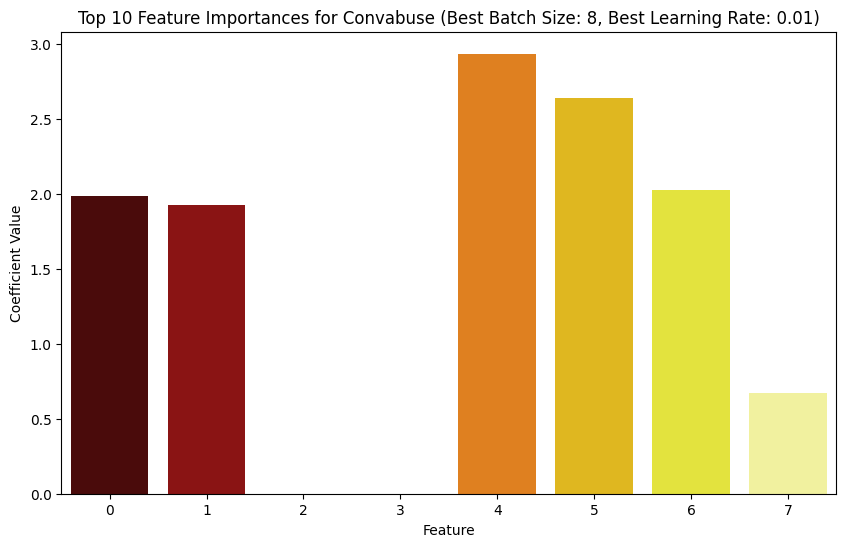

              precision    recall  f1-score   support

           0       0.69      0.45      0.54      1006
           1       0.59      0.79      0.67      1006
           2       0.82      0.43      0.56      1006
           3       0.44      0.35      0.39      1007
           4       0.49      0.83      0.62      1006

    accuracy                           0.57      5031
   macro avg       0.61      0.57      0.56      5031
weighted avg       0.61      0.57      0.56      5031



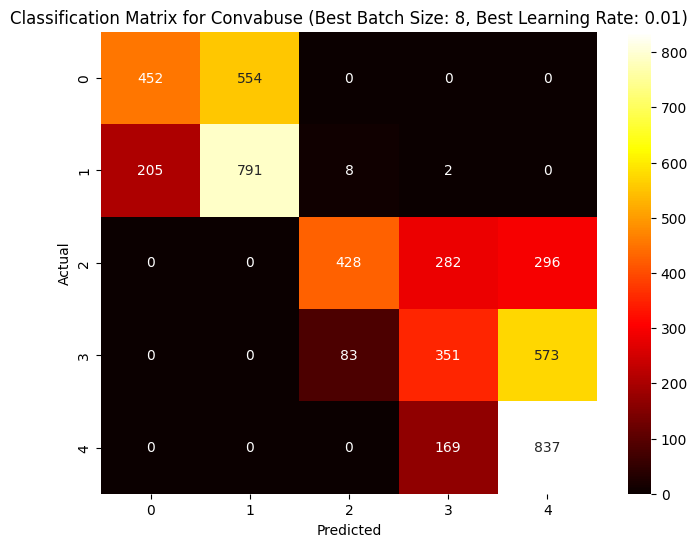

Could not perform UMAP reduction: cannot access local variable 'umap' where it is not associated with a value


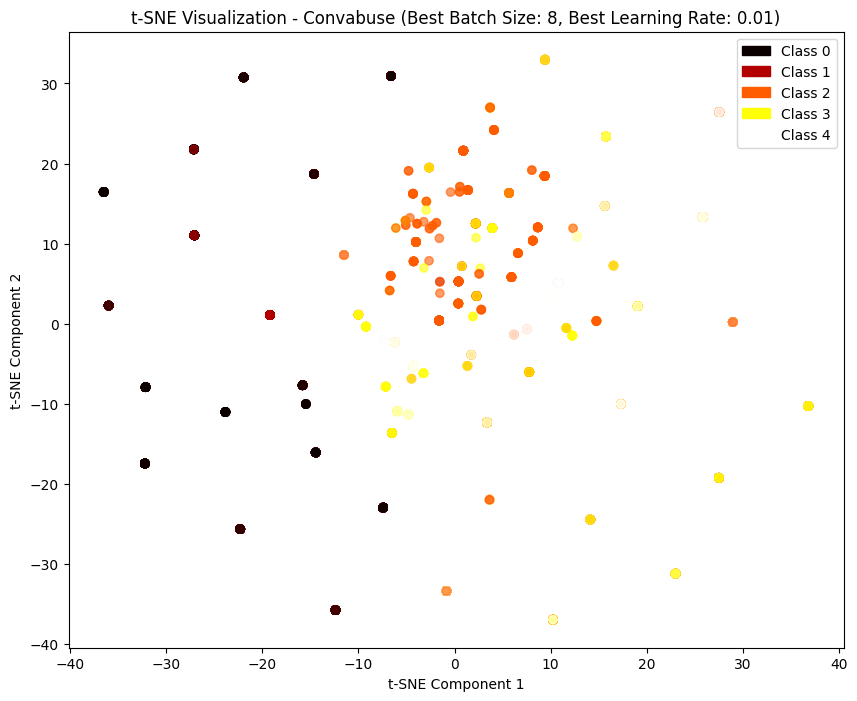

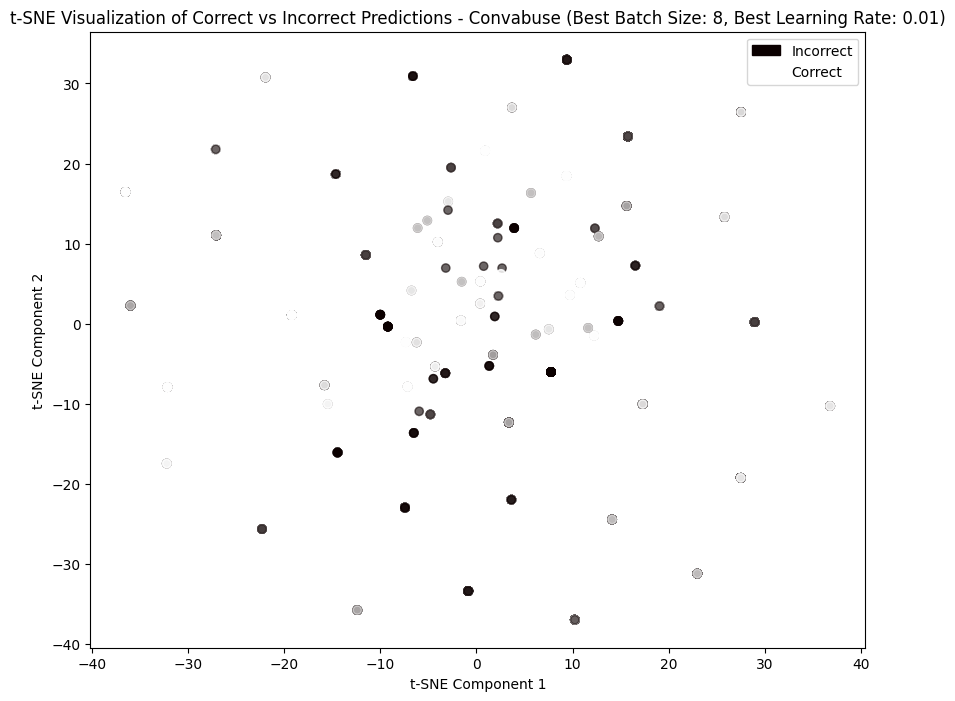

In [ ]:
resampled_results_list = neural_network_modeling(X_train=resampled_X_train, X_test=resampled_X_test, y_train=resampled_y_train, y_test=resampled_y_test, dataset="Convabuse")


Neural Network Modeling - Dataset: Convabuse

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5096 - loss: 1.2902 - val_accuracy: 0.2479 - val_loss: 1.0257 - learning_rate: 0.0100
Epoch 2/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4218 - loss: 1.0196 - val_accuracy: 0.8495 - val_loss: 0.7242 - learning_rate: 0.0100
Epoch 3/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4253 - loss: 1.0019 - val_accuracy: 0.1321 - val_loss: 0.8594 - learning_rate: 0.0100
Epoch 4/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4494 - loss: 0.9513 - val_accuracy: 0.1336 - val_loss: 0.8049 - learning_rate: 0.0100
Epoch 5/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4322 - loss: 0.9532 - val_accuracy: 0.8952 - val_loss: 0.5608 - learning_rate: 0.0100
Epoch 6/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5402 - loss: 0.9669 - val_accuracy: 0.0879 - val_loss: 0.877

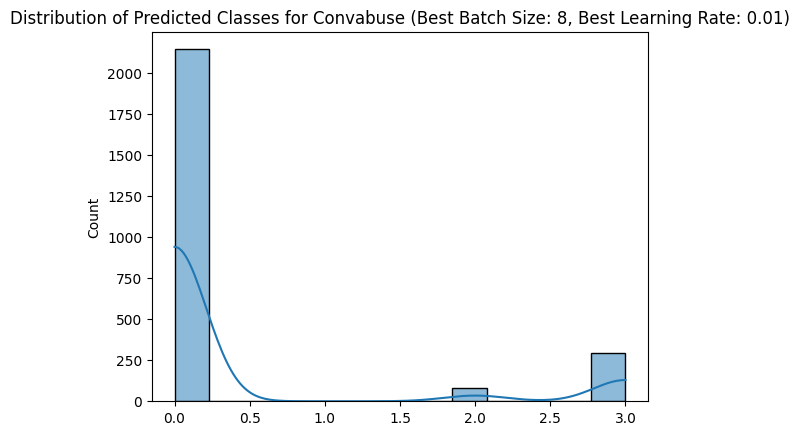

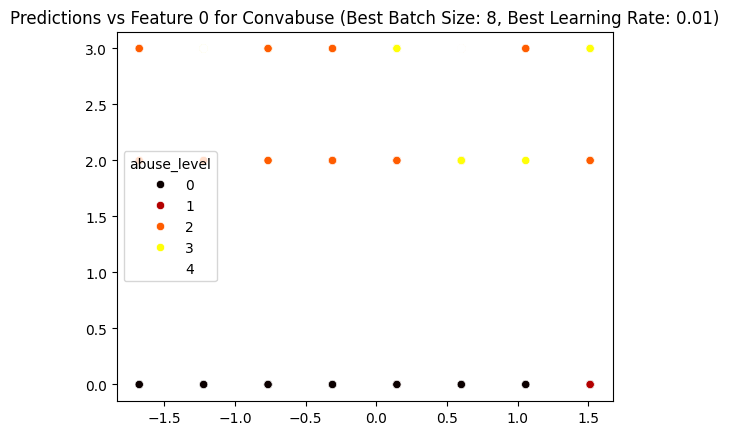

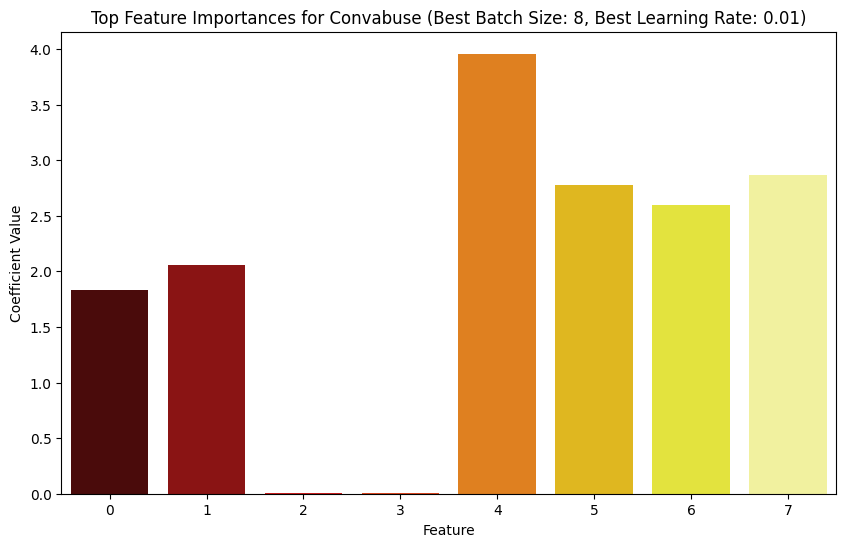

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2013
           1       0.00      0.00      0.00       132
           2       0.76      0.40      0.52       150
           3       0.53      0.90      0.66       173
           4       0.00      0.00      0.00        48

    accuracy                           0.89      2516
   macro avg       0.44      0.46      0.43      2516
weighted avg       0.83      0.89      0.85      2516



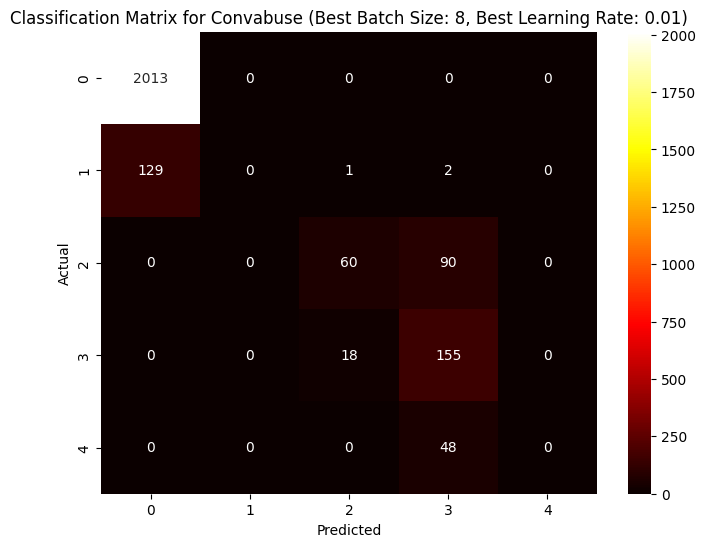

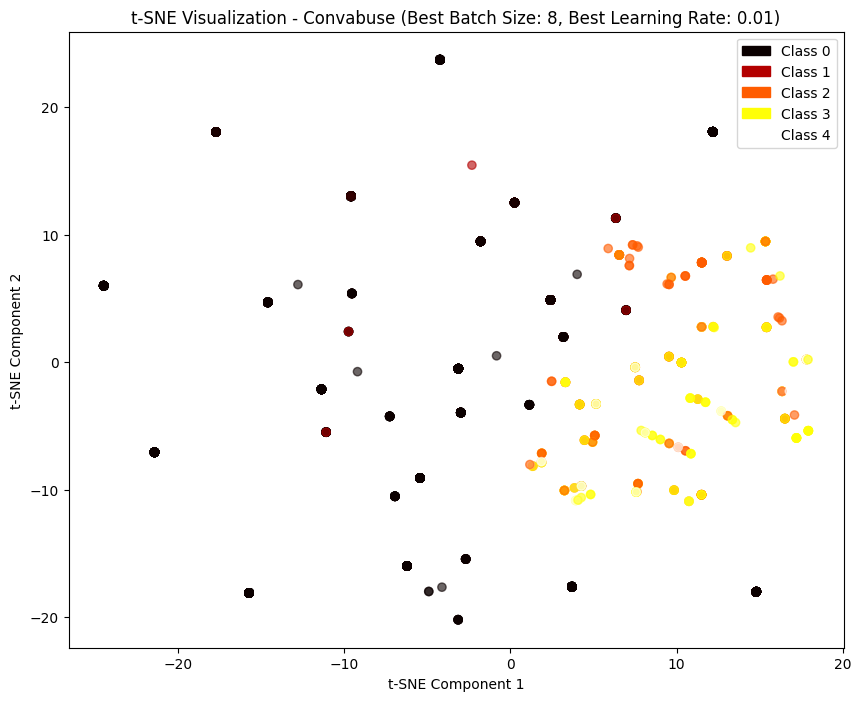

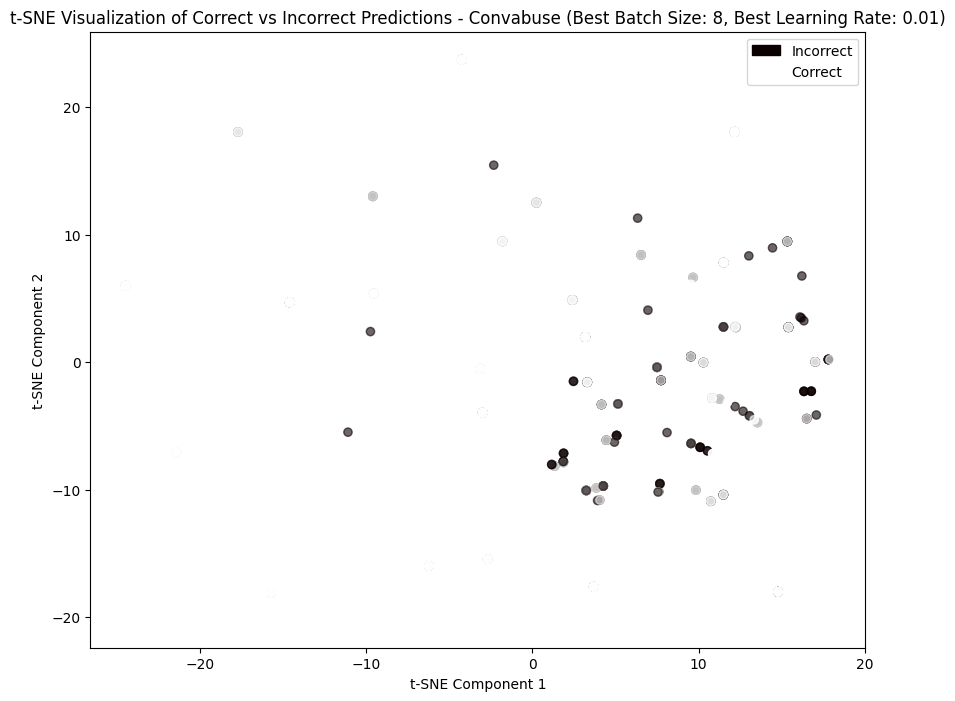

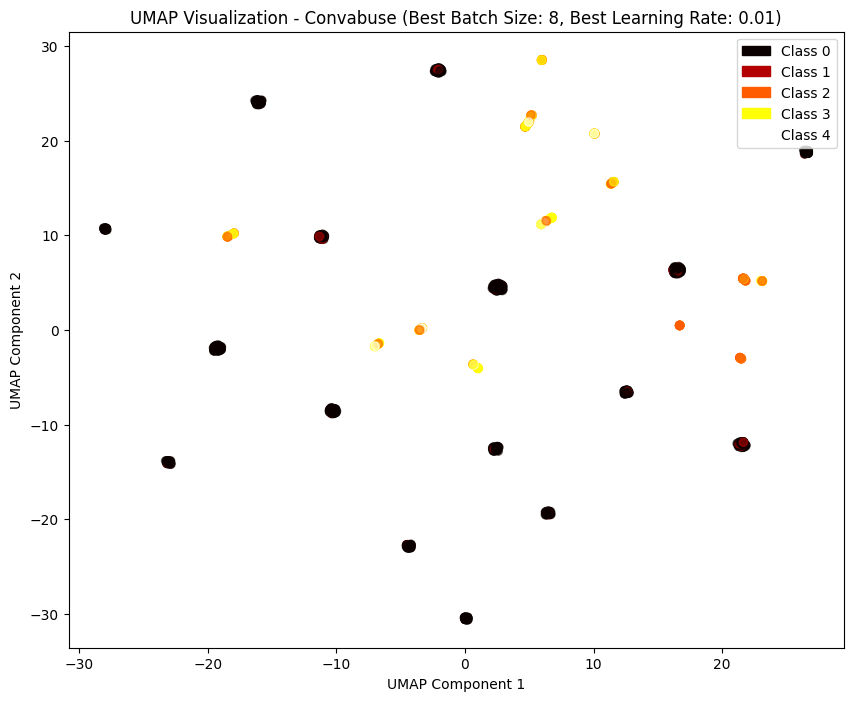

In [ ]:
weighted_X_train = imbalanced_X_train
weighted_X_test = imbalanced_X_test
weighted_y_train = imbalanced_y_train
weighted_y_test = imbalanced_y_test
weighted_dataset = "Convabuse"

results_list = []
best_model = None
best_accuracy = -float('inf') # Initialize best accuracy to negative infinity
best_batch_size = None
best_learning_rate = None
best_history = None

batch_sizes = [8]
learning_rates = [1e-2]

print(f"\nNeural Network Modeling - Dataset: {weighted_dataset}\n")

for batch_size in batch_sizes:
    for learning_rate in learning_rates:
        print(f"Training with batch size: {batch_size}, learning rate: {learning_rate}")
        # Define the neural network model with L2 regularization
        model = Sequential([
            Dense(256, activation='relu', input_shape=(weighted_X_train.shape[1],), kernel_regularizer=regularizers.L2(1e-3)),
            Dropout(0.1),
            Dense(128, activation='relu', kernel_regularizer=regularizers.L2(1e-3)),
            Dropout(0.15),
            Dense(64, activation='relu', kernel_regularizer=regularizers.L2(1e-3)),
            Dropout(0.2),
            Dense(len(np.unique(weighted_y_train)), activation='softmax')
        ])

        # Compile the model
        model.compile(optimizer=Adam(learning_rate=learning_rate),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

        # Define the ReduceLROnPlateau callback
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_delta=1e-5,
            cooldown=0,
            min_lr=1e-8,
            verbose=1,
        )

        # Train the model with the callback and class weights
        start = time.time()
        history = model.fit(weighted_X_train, weighted_y_train,
                            epochs=200,
                            batch_size=batch_size,
                            validation_split=0.2,
                            verbose=1,
                            callbacks=[reduce_lr, EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                            class_weight=class_weights_dict)
        end = time.time()
        training_time = end - start

        # Evaluate on the validation set to find the best model
        val_loss, val_accuracy = model.evaluate(weighted_X_train[int(0.8 * len(weighted_X_train)):], weighted_y_train[int(0.8 * len(weighted_y_train)):], verbose=0)

        # Check if the current model has better validation accuracy
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_model = model
            best_batch_size = batch_size
            best_learning_rate = learning_rate
            best_history = history
            best_training_time = training_time

print(f"\nBest model trained with batch size: {best_batch_size} and learning rate: {best_learning_rate}")
print(f"Training time for best model: {best_training_time:.2f} seconds")


# Evaluate the best model
loss, accuracy = best_model.evaluate(weighted_X_test, weighted_y_test, verbose=0)
y_pred = np.argmax(best_model.predict(weighted_X_test), axis=1)
f1 = f1_score(weighted_y_test, y_pred, average='weighted')
macro_f1 = f1_score(weighted_y_test, y_pred, average='macro')

print(f"\nDataset: {weighted_dataset}, Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate}, Final Test Accuracy: {accuracy}, Final Test F1-score: {f1}, Final Test Macro-F1-score: {macro_f1}")

# Store results for the best model
results_list.append((weighted_dataset, 'Neural Network', 'Adam', accuracy, f1, macro_f1, 0, best_batch_size, best_learning_rate))

# Get feature importance (using absolute sum of weights in the first layer as a proxy)
first_layer_weights = best_model.layers[0].get_weights()[0]
overall_importance = np.sum(np.abs(first_layer_weights), axis=1)
best_coefficients_data = dict(zip(range(len(overall_importance)), overall_importance))

print("Feature Importance (based on first layer weights)")
print(best_coefficients_data)

# Plot the predictions that were generated as a histogram using seaborn
sns.histplot(y_pred, kde=True)
plt.title(f'Distribution of Predicted Classes for {weighted_dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
plt.show()

# Explicitly convert y_test to a pandas Series for plotting correlation
try:
    weighted_y_test_series = pd.Series(weighted_y_test)
except Exception as e:
    print(f"Could not convert weighted_y_test to pandas Series: {e}")
    weighted_y_test_series = None

# Plot the predictions against a feature (need to select a feature)
if isinstance(weighted_X_test, pd.DataFrame) and weighted_y_test_series is not None:
    correlation_series = weighted_X_test.corrwith(weighted_y_test_series).abs()
    if not correlation_series.empty and not correlation_series.isna().all():
        best_correlated_feature = correlation_series.idxmax()
        sns.scatterplot(x=weighted_X_test[best_correlated_feature], y=y_pred, hue=weighted_y_test, palette="hot")
        plt.title(f'Predictions vs Best Correlated Feature ({best_correlated_feature}) for {weighted_dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.show()
    else:
        print("Warning: Could not find a feature with sufficient correlation for plotting.")
elif weighted_X_test.shape[1] > 0 and weighted_y_test_series is not None:
    sns.scatterplot(x=weighted_X_test[:, 0], y=y_pred, hue=weighted_y_test, palette="hot")
    plt.title(f'Predictions vs Feature 0 for {weighted_dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
    plt.show()
else:
    print("Warning: weighted_X_test is not a pandas DataFrame and has no features for plotting.")


# Sort the feature importances and plot the top 10 in descending order
sorted_coefficients = sorted(best_coefficients_data.items(), key=lambda x: x[1], reverse=True)
top_10_coefficients = sorted_coefficients[:10][::-1]
top_10_features = [item[0] for item in top_10_coefficients]
top_10_importances = [item[1] for item in top_10_coefficients]
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features, y=top_10_importances, palette="hot")
plt.ylabel('Coefficient Value')
plt.xlabel('Feature')
plt.title(f'Top Feature Importances for {weighted_dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
plt.show()

# Convert the results list into a dataframe
results = pd.DataFrame(results_list, columns=["Dataset", "Model", "Optimizer", "Accuracy", "F1-score", "Macro F1-score", "Ratio", "Best Batch Size", "Best Learning Rate"])
results['Importances'] = [best_coefficients_data]
top_10_coefficients_dict = dict(top_10_coefficients)
results['Feature Importances'] = [top_10_coefficients_dict]

# Print a classification report
print(classification_report(weighted_y_test, y_pred))

# Print a classification matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(weighted_y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='hot')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Classification Matrix for {weighted_dataset} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
plt.show()

# Prepare data for t-SNE and UMAP plots, handling 2-feature datasets
X_plot_tsne = None
tsne_title_suffix = ""
tsne_xlabel = ""
tsne_ylabel = ""

X_plot_umap = None
umap_title_suffix = ""
umap_xlabel = ""
umap_ylabel = ""

if weighted_X_test.shape[1] == 2:
    X_plot_tsne = weighted_X_test
    tsne_title_suffix = " (Original Features)"
    tsne_xlabel = "Feature 0"
    tsne_ylabel = "Feature 1"

    X_plot_umap = weighted_X_test
    umap_title_suffix = " (Original Features)"
    umap_xlabel = "Feature 0"
    umap_ylabel = "Feature 1"
elif weighted_X_test.shape[1] > 2:
    try:
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
        X_plot_tsne = tsne.fit_transform(weighted_X_test)
        tsne_xlabel = 't-SNE Component 1'
        tsne_ylabel = 't-SNE Component 2'
    except Exception as e:
        print(f"Could not perform t-SNE reduction: {e}")

    try:
        reducer = umap.UMAP(random_state=42)
        X_plot_umap = reducer.fit_transform(weighted_X_test)
        umap_xlabel = 'UMAP Component 1'
        umap_ylabel = 'UMAP Component 2'
    except ImportError:
        print("UMAP library not found. Please install it with 'pip install umap-learn'")
    except Exception as e:
        print(f"Could not perform UMAP reduction: {e}")
else: # weighted_X_test.shape[1] < 2, not enough features for 2D plot
    print("Warning: Not enough features in weighted_X_test for 2D t-SNE or UMAP visualization.")


# Use t-sne and color code by the target variable
if X_plot_tsne is not None:
    try:
        import matplotlib.patches as mpatches

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_plot_tsne[:, 0], X_plot_tsne[:, 1], c=weighted_y_test, cmap='hot', alpha=0.6)
        plt.title(f't-SNE Visualization - {weighted_dataset}{tsne_title_suffix} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.xlabel(tsne_xlabel)
        plt.ylabel(tsne_ylabel)

        classes = np.unique(weighted_y_test)
        colors = [scatter.cmap(scatter.norm(c)) for c in classes]
        handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
        plt.legend(handles=handles)

        plt.show()
    except Exception as e:
        print(f"Could not perform t-SNE visualization: {e}")

    # Use t-sne to plot correct vs incorrect predictions
    try:
        correct_predictions = (y_pred == weighted_y_test)

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_plot_tsne[:, 0], X_plot_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6)
        plt.title(f't-SNE Visualization of Correct vs Incorrect Predictions - {weighted_dataset}{tsne_title_suffix} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.xlabel(tsne_xlabel)
        plt.ylabel(tsne_ylabel)

        handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label='Incorrect'),
                    mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label='Correct')]
        plt.legend(handles=handles)

        plt.show()
    except Exception as e:
        print(f"Could not perform t-SNE visualization for correct vs incorrect predictions: {e}")

# Use UMAP and color code by the target variable
if X_plot_umap is not None:
    try:
        import umap.umap_ as umap

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_plot_umap[:, 0], X_plot_umap[:, 1], c=weighted_y_test, cmap='hot', alpha=0.6)
        plt.title(f'UMAP Visualization - {weighted_dataset}{umap_title_suffix} (Best Batch Size: {best_batch_size}, Best Learning Rate: {best_learning_rate})')
        plt.xlabel(umap_xlabel)
        plt.ylabel(umap_ylabel)

        classes = np.unique(weighted_y_test)
        colors = [scatter.cmap(scatter.norm(c)) for c in classes]
        handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
        plt.legend(handles=handles)

        plt.show()
    except ImportError:
        print("UMAP library not found. Please install it with 'pip install umap-learn'")
    except Exception as e:
        print(f"Could not perform UMAP visualization: {e}")

neural_network_TSNE[weighted_dataset] = X_plot_tsne
neural_network_UMAP[weighted_dataset] = X_plot_umap

weighted_results_list = results


Neural Network Modeling - Dataset: Convabuse

Training with batch size: 8, learning rate: 0.01
Epoch 1/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8584 - loss: 0.5109 - val_accuracy: 0.8743 - val_loss: 0.3510 - learning_rate: 0.0100
Epoch 2/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8710 - loss: 0.3771 - val_accuracy: 0.8743 - val_loss: 0.3333 - learning_rate: 0.0100
Epoch 3/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8778 - loss: 0.3626 - val_accuracy: 0.8952 - val_loss: 0.3190 - learning_rate: 0.0100
Epoch 4/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8844 - loss: 0.3511 - val_accuracy: 0.8952 - val_loss: 0.3289 - learning_rate: 0.0100
Epoch 5/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8655 - loss: 0.3750 - val_accuracy: 0.8952 - val_loss: 0.3165 - learning_rate: 0.0100
Epoch 6/200
1006/1006 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8769 - loss: 0.3534 - val_accuracy: 0.8743 - val_loss: 0.329

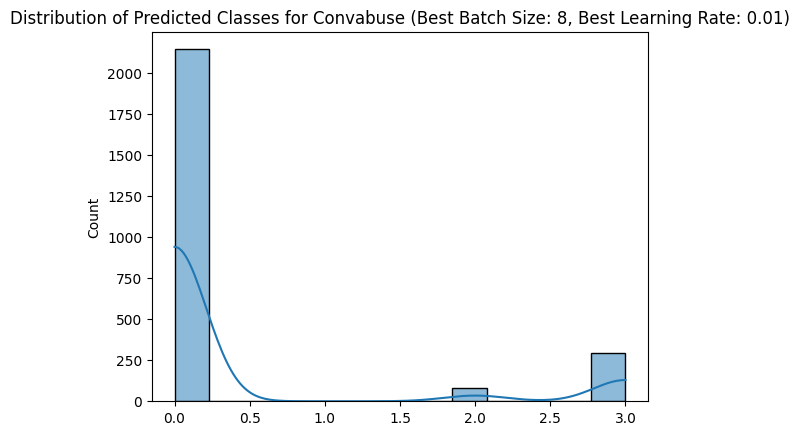

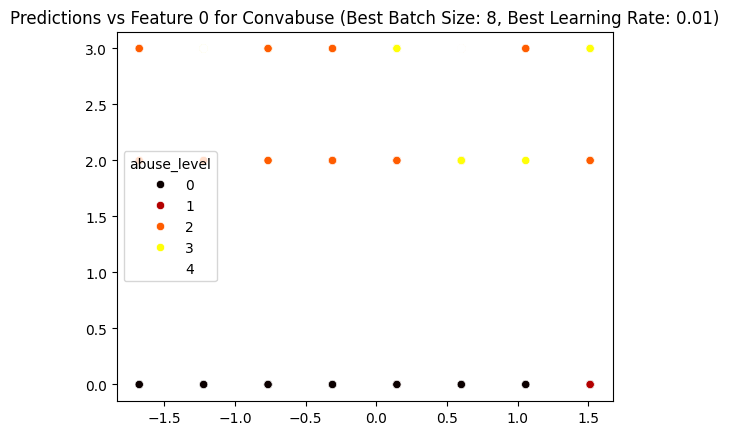

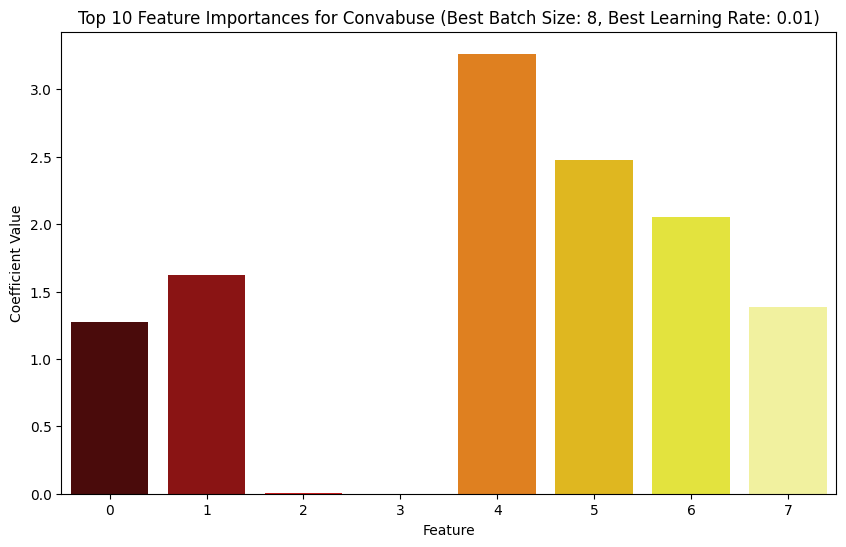

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2013
           1       0.00      0.00      0.00       132
           2       0.76      0.40      0.52       150
           3       0.53      0.90      0.66       173
           4       0.00      0.00      0.00        48

    accuracy                           0.89      2516
   macro avg       0.44      0.46      0.43      2516
weighted avg       0.83      0.89      0.85      2516



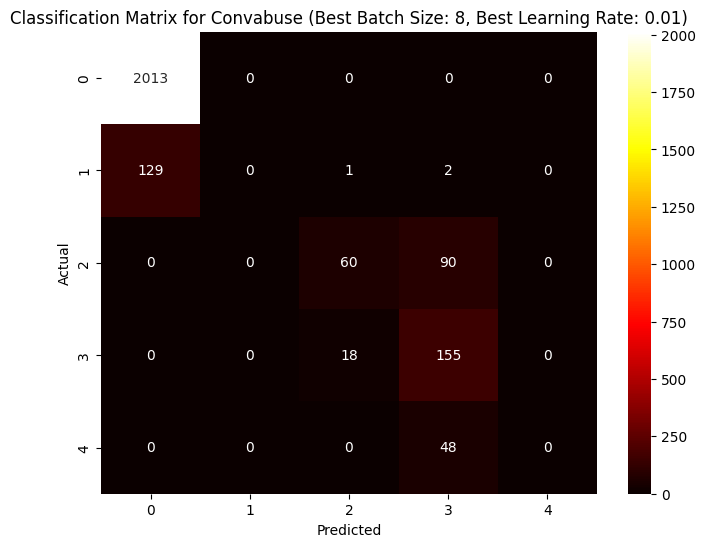

Could not perform UMAP reduction: cannot access local variable 'umap' where it is not associated with a value


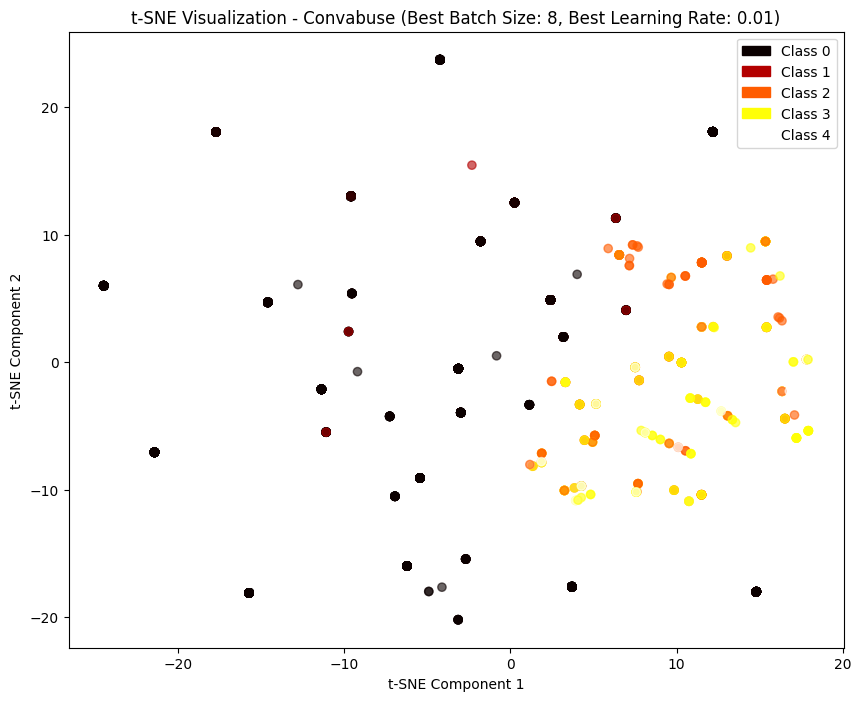

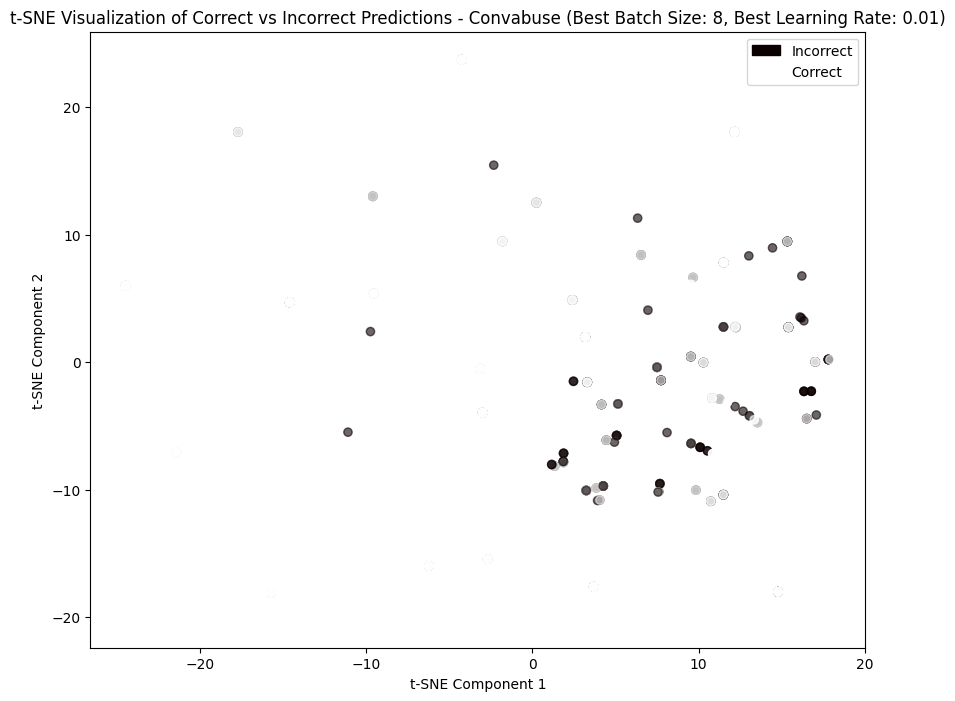

In [ ]:
imbalanced_results_list = neural_network_modeling(X_train=imbalanced_X_train, X_test=imbalanced_X_test, y_train=imbalanced_y_train, y_test=imbalanced_y_test, dataset="Convabuse",

## Logistic Regression Conclusions

In [ ]:
neural_network_TSNE

{'Convabuse': array([[  7.6761875,  -9.524904 ],
        [ -3.1332793,  -0.508913 ],
        [-15.7120075, -18.083683 ],
        ...,
        [-17.698093 ,  18.051481 ],
        [-15.7120075, -18.083683 ],
        [ -9.531011 ,   5.390596 ]], dtype=float32)}

In [ ]:
neural_network_UMAP

{'Convabuse': None}

In [ ]:
# Pickle both dictionaries
pickle_path = "/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/"

with open(f'{pickle_path}neural-network-TSNE-dict-original-convabuse.pkl', 'wb') as f:
    pickle.dump(neural_network_TSNE, f)
with open(f'{pickle_path}neural-network-UMAP-dict-original-convabuse.pkl', 'wb') as f:
    pickle.dump(neural_network_UMAP, f)

In [ ]:
# Compile the results into logistic_regression_model_results
neural_network_model_results = [resampled_results_list, weighted_results_list, imbalanced_results_list]
neural_network_model_results = [pd.DataFrame(item) for item in neural_network_model_results]

neural_network_model_summary = pd.concat(neural_network_model_results, ignore_index=True)
neural_network_model_summary["Balance"] = ["Resampled", "Weighted", "Imbalanced"]

# Rename Top 10 Importances to Feature Importances
neural_network_model_summary = neural_network_model_summary.rename(columns={"Top 10 Importances": "Feature Importances"})
neural_network_model_summary

,Dataset,Model,Optimizer,Accuracy,F1-score,Macro F1-score,Ratio,Best Batch Size,Best Learning Rate,Importances,Feature Importances,Balance
0,Convabuse,Neural Network,Adam,0.568277,0.556506,0.556540,0,8,0.01,"{0: 1.986209, 1: 1.9249209, 2: 1.1851645e-36, ...","{2: 1.1851645e-36, 3: 1.2151944e-36, 7: 0.6715...",Resampled
1,Convabuse,Neural Network,Adam,0.885533,0.852027,0.431073,0,8,0.01,"{0: 1.8343625, 1: 2.0527735, 2: 0.0020518668, ...","{2: 0.0020518668, 3: 0.003013769, 0: 1.8343625...",Weighted
2,Convabuse,Neural Network,Adam,0.885533,0.852027,0.431073,0,8,0.01,"{0: 1.2716117, 1: 1.6220874, 2: 0.0054562297, ...","{3: 0.0010522484, 2: 0.0054562297, 0: 1.271611...",Imbalanced


In [ ]:
neural_network_model_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/model12_neural-network-summary_convabuse.csv", index=False)